In [1]:
import app
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import rasterio as rio
import rasterio.plot as rplt
import rasterio.windows  as rw
from rasterio.transform import Affine
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np
import xarray as xr

app.setup_logger(use_console_handler=True, use_file_handler=False)

In [2]:
base_directory = r"D:\PhD\21_Experiments\TidesDamageDriver"
drainages_folder = os.path.join(
    base_directory, "02_processed", "03_drainages"
)
data_dmg_folder = os.path.join(
    base_directory, "03_cleaned", "dmg_resampled"
)
lai_path = os.path.join(
    base_directory, "01_raw", "lai2020_vulnerability", "vulnerable.nc"
)
fuerst_path = os.path.join(
    base_directory, "01_raw", "fuerst2016_psi", "psi.nc"
)
iceshelf_folder = os.path.join(
    base_directory, "01_raw", "greene2022_iceshelves"
)

years = [2016, 2018, 2019, 2020]
xmin = 2.50e6
xmax = 2.77e6
ymax = -0.215e6
ymin = -0.591e6

In [3]:
all_iceshelves_files = os.listdir(iceshelf_folder)
iceshelves = [
    gpd.read_file(os.path.join(iceshelf_folder, f)).cx[xmin:xmax, ymin:ymax]
    for f in all_iceshelves_files
    if f.endswith(".shp") and any([str(s) in f for s in years])
]
ice_buffer = 150
for ice in iceshelves:
    ice.geometry = ice.buffer(ice_buffer)
    ice = ice.dissolve()
    ice.geometry = ice.buffer(-ice_buffer)

buffer = 6e3
iceshelves_buffer = [i.buffer(buffer) for i in iceshelves]

In [4]:
gdf_0 = app.lakes.plotting.get_geodataframes(drainages_folder, ["drainages.shp"])[0]

In [5]:
gdf_0

,index,criteria,window,lake id,type,tile,ifile_0,area,file_0,date-0,...,volume-0,median-1,mean-1,volume-1,std_depth,year,justificat,start_date,end_date,geometry
0,0,181_5_L8_2_L8_727_2017-01-14_2017-01-22_drain,0,727.0,drain,181,5,53100.0,tile-181_L8_2017-01-10_2017-01-18_30m.tif,2017-01-14,...,40620.850682,0.000000,0.000000,0.000000,NaN,2016,drainage,2017-01-11,2017-01-25,"MULTIPOLYGON (((2597640 -514590, 2597640 -5146..."
1,2,181_6_S2_2_L8_584_2017-01-15_2017-01-22_drain,0,584.0,drain,181,6,60300.0,tile-181_S2_2017-01-10_2017-01-20_10m.tif,2017-01-15,...,39906.182206,0.000000,0.000000,0.000000,NaN,2016,drainage,2017-01-31,2017-02-03,"POLYGON ((2597550 -514080, 2597580 -514080, 25..."
2,3,181_8_L8_1_S2_161_2017-01-30_2017-02-04_shrink,0,161.0,shrink,181,8,96300.0,tile-181_L8_2017-01-26_2017-02-03_30m.tif,2017-01-30,...,123562.726021,0.170166,0.172314,2016.074359,0.362372,2016,drainage,2017-01-11,2017-01-18,"POLYGON ((2576310 -471300, 2576340 -471300, 25..."
3,5,182_5_L8_2_L8_575_2017-01-14_2017-01-22_shrink,0,575.0,shrink,182,5,36000.0,tile-182_L8_2017-01-10_2017-01-18_30m.tif,2017-01-14,...,271096.532965,0.860840,0.868432,37516.248894,0.535359,2016,drainage,2017-01-16,2017-01-23,"MULTIPOLYGON (((2556240 -445050, 2556240 -4451..."
4,8,183_7_S2_2_L8_90_2017-01-15_2017-01-22_shrink,0,90.0,shrink,183,7,90900.0,tile-183_S2_2017-01-10_2017-01-20_10m.tif,2017-01-15,...,130987.440419,0.222290,0.222290,600.183105,0.717127,2016,drainage,2017-01-27,2017-02-03,"POLYGON ((2565840 -271140, 2565870 -271140, 25..."
5,14,181_6_S2_2_L8_22_2017-01-15_2017-01-22_shrink,0,22.0,shrink,181,6,1800.0,tile-181_S2_2017-01-10_2017-01-20_10m.tif,2017-01-15,...,119482.474029,0.274536,0.291931,2890.118408,0.294078,2016,drainage,2017-02-03,2017-02-10,"MULTIPOLYGON (((2569200 -467880, 2569200 -4679..."
6,15,181_8_L8_1_S2_388_2017-01-30_2017-02-04_shrink,0,388.0,shrink,181,8,900.0,tile-181_L8_2017-01-26_2017-02-03_30m.tif,2017-01-30,...,43381.439209,0.471680,0.500662,3604.769182,0.199416,2016,drainage,2017-02-03,2017-02-10,"MULTIPOLYGON (((2599470 -492540, 2599440 -4925..."
7,17,182_13_L8_1_L8_300_2019-01-30_2019-02-07_shrink,0,300.0,shrink,182,13,99900.0,tile-182_L8_2019-01-26_2019-02-03_30m.tif,2019-01-30,...,91389.173824,0.585693,0.595006,7497.070205,0.263434,2018,drainage,2019-01-31,2019-02-08,"POLYGON ((2573160 -400260, 2573250 -400260, 25..."
8,19,181_11_L8_1_L8_447_2020-01-22_2020-01-30_drain,0,447.0,drain,181,11,75600.0,tile-181_L8_2020-01-18_2020-01-26_30m.tif,2020-01-22,...,151999.203873,0.000000,0.000000,0.000000,NaN,2019,drainage,2020-01-18,2020-01-21,"POLYGON ((2583750 -477600, 2583780 -477600, 25..."
9,20,181_2_L8_1_S2_53_2019-12-13_2019-12-16_shrink,0,53.0,shrink,181,2,118800.0,tile-181_L8_2019-12-09_2019-12-17_30m.tif,2019-12-13,...,139426.153421,0.479370,0.487222,7892.992795,0.339331,2019,drainage,2019-12-10,2019-12-15,"POLYGON ((2567100 -471300, 2567190 -471300, 25..."


<Axes: >

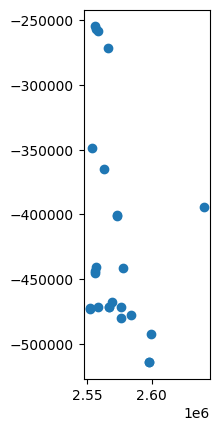

In [6]:
gdf_0.centroid.plot()

In [7]:
dmgs = []
dmgs_transforms = []
dmgs_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_folder, f'{year}', f'S1_{year}1101_{year}1110_3000m_dmg.tif'
    )
    with rio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform
        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
            raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        masked = masked
        masked = (masked / np.nanmax(masked)).copy()

    dmgs.append(masked)
    dmgs_transforms.append(masked_transform)
    dmgs_meta.append(meta)

dmg_results = []
for dmg in dmgs:
    res = app.dmg.categorize(dmg, number_bins=10, medium=7, high=9)
    dmg_results.append(res)

dmg_limit_medium = float(np.array([res["medium"]["limits"][0] for res in dmg_results]).mean())
dmg_limit_high = float(np.array([res["high"]["limits"][0] for res in dmg_results]).mean())
dmg_fractions = (float(dmg_results[0]["low"]["fraction"]), float(dmg_results[0]["medium"]["fraction"]), float(dmg_results[0]["high"]["fraction"]))


In [8]:
acts = []
acts_transforms = []
acts_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_folder, f'{year}', f'S1_{year}1101_{year}1110_3000m_act.tif'
    )
    with rio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform

        raster[raster == 0] = np.nan
        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
            raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        masked = masked
        masked = (masked / np.nanmax(masked)).copy()
    acts.append(masked)
    acts_transforms.append(masked_transform)
    acts_meta.append(meta)

act_results = []
for act in acts:
    res = app.dmg.categorize(act, number_bins=10, medium=2, high=8)
    act_results.append(res)

act_limit_medium = float(np.array([res["medium"]["limits"][0] for res in act_results]).mean())
act_limit_high = float(np.array([res["high"]["limits"][0] for res in act_results]).mean())
act_fractions = (float(act_results[0]["low"]["fraction"]), float(act_results[0]["medium"]["fraction"]), float(act_results[0]["high"]["fraction"]))

In [9]:
lai = xr.open_dataset(lai_path, engine="netcdf4")
da = lai["vulnerable"]
da = da.rio.write_crs("EPSG:3031", inplace=True)
lai_raster = da.values  # 2D NumPy array
lai_transform = da.rio.transform()  # Affine transform from xarray
lai_raster_0 = lai_raster.copy()
lai_raster_0[lai_raster != 0] = np.nan
lai_raster_1 = lai_raster.copy()
lai_raster_1[lai_raster != 1] = np.nan

In [10]:
fuerst = xr.open_dataset(fuerst_path, engine="netcdf4")
da = fuerst["PSI"]
da = da.rio.write_crs("EPSG:3031", inplace=True)
fuerst_raster = da.values  # 2D NumPy array
fuerst_transform = da.rio.transform()  # Affine transform from xarray
fuerst_raster_1 = fuerst_raster.copy()
fuerst_raster_1[fuerst_raster != 1] = np.nan

In [11]:
dmg_values = []
dmg_percentile = []
act_values = []
act_percentile = []
lai_values = []
fuerst_values = []

for i, row in enumerate(gdf_0.iterrows()):
    row = row[1]
    i_year = years.index(int(row["year"]))
    centroid = row["geometry"].centroid
    dmg_values.append(
        app.lakes.tiffiles.get_value(
            dmgs[i_year],
            dmgs_transforms[i_year],
            centroid.x,
            centroid.y,
        )
    )

    act_values.append(
        app.lakes.tiffiles.get_value(
            acts[i_year],
            acts_transforms[i_year],
            centroid.x,
            centroid.y,
        )
    )
    lai_values.append(
        app.lakes.tiffiles.get_value(
            lai_raster,
            lai_transform,
            centroid.x,
            centroid.y,
        )
    )
    fuerst_values.append(
        app.lakes.tiffiles.get_value(
            fuerst_raster,
            fuerst_transform,
            centroid.x,
            centroid.y,
        )
    )



gdf_0["dmg"] = dmg_values
gdf_0["act"] = act_values
gdf_0["lai"] = lai_values
gdf_0["fuerst"] = fuerst_values

In [12]:
gdf_0["dmg_cat"] = "low"
gdf_0.loc[gdf_0["dmg"] >= dmg_limit_medium, "dmg_cat"] = "medium"
gdf_0.loc[gdf_0["dmg"] >= dmg_limit_high, "dmg_cat"] = "high"
gdf_0["act_cat"] = "low"
gdf_0.loc[gdf_0["act"] >= act_limit_medium, "act_cat"] = "medium"
gdf_0.loc[gdf_0["act"] >= act_limit_high, "act_cat"] = "high"

In [13]:
gdf_0["fuerst+lai"] = gdf_0["lai"] + gdf_0["fuerst"]

In [14]:
print(gdf_0[['lai', 'fuerst', "fuerst+lai", 'dmg', "dmg_cat", 'act', 'act_cat']])

    lai  fuerst  fuerst+lai       dmg dmg_cat       act act_cat
0   NaN     NaN         NaN  0.263605    high  0.365044  medium
1   NaN     NaN         NaN  0.263605    high  0.365044  medium
2   0.0     0.0         0.0  0.034623  medium  0.128102     low
3   1.0     0.0         1.0  0.213334    high  0.694820    high
4   1.0     0.0         1.0  0.356259    high  0.574090  medium
5   0.0     0.0         0.0  0.115534  medium  0.539153  medium
6   0.0     0.0         0.0  0.082511  medium  0.656507    high
7   0.0     0.0         0.0  0.284860    high  0.313371  medium
8   0.0     0.0         0.0  0.289971    high  0.296997  medium
9   NaN     NaN         NaN  0.206265    high  0.583265  medium
10  0.0     0.0         0.0  0.075376  medium  0.306274  medium
11  0.0     0.0         0.0  0.135486  medium  0.681241    high
12  0.0     0.0         0.0  0.258913    high  0.559670  medium
13  0.0     0.0         0.0  0.256579    high  0.386947  medium
14  0.0     0.0         0.0  0.200970   

In [15]:
gdf_0.to_file(os.path.join(drainages_folder, "drainages_values.shp"))

c:\Users\jsommer1\[Code]\HydrofractureShackleton_2023\.venvDrainges\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field date-0 create as date field, though DateTime requested.
  ogr_write(
c:\Users\jsommer1\[Code]\HydrofractureShackleton_2023\.venvDrainges\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field start-0 create as date field, though DateTime requested.
  ogr_write(
c:\Users\jsommer1\[Code]\HydrofractureShackleton_2023\.venvDrainges\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field end-0 create as date field, though DateTime requested.
  ogr_write(
c:\Users\jsommer1\[Code]\HydrofractureShackleton_2023\.venvDrainges\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field date-1 create as date field, though DateTime requested.
  ogr_write(
c:\Users\jsommer1\[Code]\HydrofractureShackleton_2023\.venvDrainges\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field start-1 create as date field, though DateTime requested.
  ogr_write(
c:\Users\jsomm